# Sessao 0 - 19/08/2026

## Ecosistema Geoespacial

Antes de mergulharmos na amplitude dos ecossistemas geoespaciais, vamos compreender melhor a nossa comunidade FTL Brasil. 

### Quem somos? De onde somos? 

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt 
import os 


In [2]:
os.getcwd()

'/Users/macuser/Documents/UN/ebook/fundamentals_gis_rs/week0'

In [3]:
# lets read our csv with the location of everyone
df = pd.read_excel('data/NOS-FTL-Brasil.xlsx')

df.head()

,ID,"De onde você é? (Escreva como: Cidade/SG. exemplo: Pindamonhangaba/SP . Tarauca/AC , catole do rocha/PB)\n\n"
0,1,Fortaleza-CE
1,2,RECIFE/PE
2,3,Limeira/SP
3,4,Curitiba - Paraná
4,5,Viamão/RS


## Limpeza de dados

Aquilo que todo cientista de dados ama.

Como o texto livre tem bastante variação, como separadores diferentes (`/`, `-`, `,`), estado abreviado vs. nome completo, prefixos tipo "Sou de..." — fazemos só uma limpeza leve antes de geocodificar. Não tentamos separar cidade/estado manualmente: casos como `"Minas - Pouso Alegre"` (ordem invertida!) tornariam isso frágil. Em vez disso, mandamos a string inteira para o Nominatim, que já é bom em interpretar texto livre e na prática resolve isso para gente.

In [4]:
place= df.columns[1]
df.rename(columns={place:'lugar'},inplace=True)

In [5]:
import re

def clean_place(raw: str) -> str:
    s = raw.strip()
    s = re.sub(r'(?i)^sou de\s+', '', s)   # tira prefixos tipo "Sou de Sobral/CE"
    s = re.sub(r'\s+', ' ', s)              # espaços duplicados
    s = s.strip(' -,/')                     # separadores soltos na ponta
    return s

df['lugar_clean'] = df['lugar'].apply(clean_place)
df['lugar_clean'].unique()

<ArrowStringArray>
[            'Fortaleza-CE',                'RECIFE/PE',
               'Limeira/SP',        'Curitiba - Paraná',
                'Viamão/RS',                'Recife/PE',
                'Fortaleza',                 'Betim/MG',
   'São José dos Campos/SP',                'Toledo/PR',
            'Santarém/Pará',          'Santarém - Pará',
                  'Ijuí/RS',            'Fortaleza, ce',
               'Niterói/RJ',              'Gravataí/RS',
         'Florianópolis/SC',               'Pinhais/PR',
               'Goiânia/GO', 'Campos dos Goytacazes/RJ',
      'Rio de Janeiro / RJ',           'Porto velho/RO',
        'Campina Grande/PB',                 'Belém/PA',
              'Brasília/DF',      'Lauro de Freitas/BA',
          'Passa Quatro/MG',       'Glória do Goitá/PE',
               'Betim - MG',            'Araraquara/SP',
              'Floresta/PR',             'Rio Claro/SP',
   'Presidente Prudente/SP',           'Santa Maria/RS',
            

### Geocodificação

Agora vamos transformar cada `lugar` (texto livre, do jeito que cada pessoa preencheu no formulário) em coordenadas (latitude, longitude), usando a API pública do [Nominatim](https://nominatim.org/) (OpenStreetMap).

In [6]:
from pathlib import Path
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

CACHE_PATH = Path('data/geocoded_cache.csv')

if CACHE_PATH.exists():
    # cache na parada toda, evita bater na API do Nominatim de novo
    cache = pd.read_csv(CACHE_PATH)
else:
    # user_agent é obrigatório pela política de uso do Nominatim
    geolocator = Nominatim(user_agent='ftl-brasil-tmj', 
                           timeout=10)
    # 1 requisição por segundo
    # swallow_exceptions evita que uma falha derrube o loop
    geocode = RateLimiter(geolocator.geocode, 
                          min_delay_seconds=1, 
                          error_wait_seconds=5,
                           max_retries=2, 
                           swallow_exceptions=True)

    unique_places = df[['lugar_clean']].drop_duplicates().reset_index(drop=True)
    unique_places['location'] = unique_places['lugar_clean'].apply(lambda p: geocode(p, country_codes='br'))
    unique_places['lat'] = unique_places['location'].apply(lambda loc: loc.latitude if loc else None)
    unique_places['lon'] = unique_places['location'].apply(lambda loc: loc.longitude if loc else None)
    unique_places['matched_address'] = unique_places['location'].apply(lambda loc: loc.address if loc else None)

    cache = unique_places[['lugar_clean', 'lat', 'lon', 'matched_address']]
    cache.to_csv(CACHE_PATH, index=False)

# unimos no nosso antigo df
df = df.merge(cache, on='lugar_clean', how='left')

# verificamos aqui os dados que nao conseguiram ser geocodificados
nao_geocodificados = df[df['lat'].isna()]
print(f"{len(nao_geocodificados)} de {len(df)} linhas não foram geocodificadas")
nao_geocodificados

0 de 57 linhas não foram geocodificadas


,ID,lugar,lugar_clean,lat,lon,matched_address


In [7]:
df.head()

,ID,lugar,lugar_clean,lat,lon,matched_address
0,1,Fortaleza-CE,Fortaleza-CE,-3.793217,-38.528036,"Fortaleza, Ceará, Região Nordeste, Brasil"
1,2,RECIFE/PE,RECIFE/PE,-8.058493,-34.884819,"Recife, Pernambuco, Região Nordeste, Brasil"
2,3,Limeira/SP,Limeira/SP,-22.561507,-47.401766,"Limeira, São Paulo, Região Sudeste, Brasil"
3,4,Curitiba - Paraná,Curitiba - Paraná,-25.429596,-49.271272,"Curitiba, Paraná, Região Sul, Brasil"
4,5,Viamão/RS,Viamão/RS,-30.081934,-51.026193,"Viamão, Rio Grande do Sul, Região Sul, Brasil"


In [8]:
# vamos converter nossos dados em um geodataframe para manipular espacialmente

gdf = gpd.GeoDataFrame(
    df.dropna(subset=['lat', 'lon']),
    geometry=gpd.points_from_xy(df['lon'], df['lat']),
    crs='EPSG:4326',
)
gdf.head()

,ID,lugar,lugar_clean,lat,lon,matched_address,geometry
0,1,Fortaleza-CE,Fortaleza-CE,-3.793217,-38.528036,"Fortaleza, Ceará, Região Nordeste, Brasil",POINT (-38.52804 -3.79322)
1,2,RECIFE/PE,RECIFE/PE,-8.058493,-34.884819,"Recife, Pernambuco, Região Nordeste, Brasil",POINT (-34.88482 -8.05849)
2,3,Limeira/SP,Limeira/SP,-22.561507,-47.401766,"Limeira, São Paulo, Região Sudeste, Brasil",POINT (-47.40177 -22.56151)
3,4,Curitiba - Paraná,Curitiba - Paraná,-25.429596,-49.271272,"Curitiba, Paraná, Região Sul, Brasil",POINT (-49.27127 -25.4296)
4,5,Viamão/RS,Viamão/RS,-30.081934,-51.026193,"Viamão, Rio Grande do Sul, Região Sul, Brasil",POINT (-51.02619 -30.08193)


<Axes: >

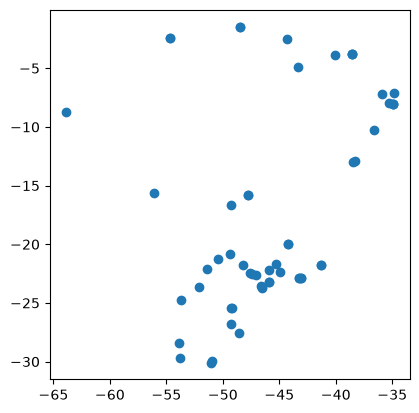

In [9]:
# vamo espiar rapidamente esses dados 
gdf.plot()

### improving the plot

Dá para melhorar isso ne? Fala tu 

- Como? 

Vamos utilizar os dados que estão em nossos ecossistema geoespacial.

Começando pela biblioteca GEOBR. Veja mais em nossa [Awesome-FTL page](/awesome-geospatial/index).



In [10]:
# baixando o polígono da nossa terra brasil
import geobr

# Mapa de localização dos participantes

In [11]:
# estados do Brasil, direto do IBGE via geobr
brasil_gdf = geobr.read_state(year=2020)
brasil_gdf.head()

,code_state,name_state,abbrev_state,code_region,name_region,year,geometry
0,11.0,Rondônia,RO,1.0,Norte,2020.0,"POLYGON ((-65.3815 -10.42907, -65.37916 -10.41..."
1,12.0,Acre,AC,1.0,Norte,2020.0,"POLYGON ((-71.07772 -9.82774, -71.08554 -9.839..."
2,13.0,Amazonas,AM,1.0,Norte,2020.0,"POLYGON ((-69.89403 -4.00068, -69.7123 -3.0006..."
3,14.0,Roraima,RR,1.0,Norte,2020.0,"POLYGON ((-63.95934 2.46763, -63.96041 2.47416..."
4,15.0,Pará,PA,1.0,Norte,2020.0,"MULTIPOLYGON (((-51.42367 -0.43661, -51.42073 ..."


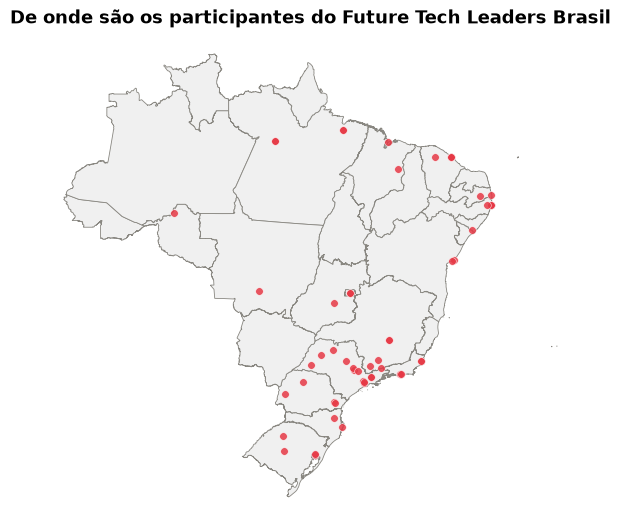

In [12]:
# brasil_gdf vem em SIRGAS2000 (EPSG:4674), nossos pontos em WGS84 (EPSG:4326)
# -- reprojetamos os pontos pro mesmo CRS do polígono antes de sobrepor os dois
gdf_plot = gdf.to_crs(brasil_gdf.crs)

fig, ax = plt.subplots(figsize=(7, 8))

brasil_gdf.plot(ax=ax, color='#f0f0f0', edgecolor='#898781', linewidth=0.6)
gdf_plot.plot(ax=ax, markersize=30, color='#e63946', alpha=0.85, edgecolor='white', linewidth=0.4)

ax.set_title('De onde são os participantes do Future Tech Leaders Brasil', fontsize=13, fontweight='bold')
ax.set_axis_off()
plt.show()

## Dá para melhorar? certamente

<Axes: >

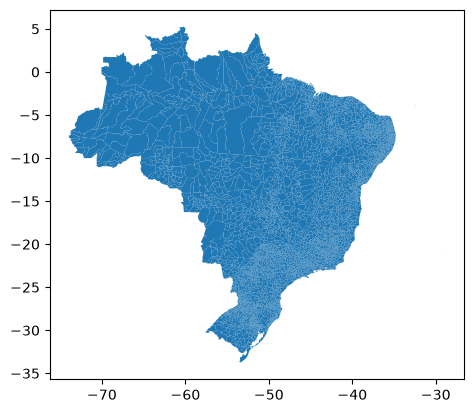

In [66]:
# baixando os dados de municipipo
muni = geobr.read_municipality(year=2020)
muni.plot()

<Axes: >

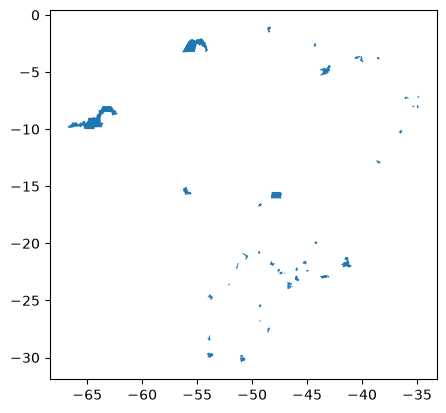

In [73]:
## vamos fazer uma spatial query para pegar os municipios

new_gdf = muni.sjoin(
    gdf.to_crs(muni.crs),
    how="inner",
    predicate="intersects"
)

# quick plot
new_gdf.plot()

In [77]:
new_gdf.columns

Index(['code_muni', 'name_muni', 'code_state', 'abbrev_state', 'name_state',
       'code_region', 'name_region', 'year', 'geometry', 'index_right', 'ID',
       'lugar', 'lugar_clean', 'lat', 'lon', 'matched_address'],
      dtype='str')

In [86]:
# adicionamos uma nova coluna com o numero de participantes por cidade
nn = new_gdf.groupby('name_muni').agg(
    num_part=('code_muni','count')
)[['num_part']]

# merge das informacoes
new_gdf = new_gdf.merge(
    nn,
    how='inner',
    on='name_muni'
)

## agora o nosso gdf tem o numero de alunos por cidade
new_gdf.head(2)

,code_muni,name_muni,code_state,abbrev_state,name_state,code_region,name_region,year,geometry,index_right,ID,lugar,lugar_clean,lat,lon,matched_address,num_part_x,num_part_y
0,1100205.0,Porto Velho,11.0,RO,Rondônia,1.0,Norte,2020.0,"POLYGON ((-62.86662 -7.97587, -62.85336 -7.987...",22,23,Porto velho/RO,porto velho/ro,-8.749453,-63.873544,"Porto Velho, Rondônia, Região Norte, Brasil",1,1
1,1501402.0,Belém,15.0,PA,Pará,1.0,Norte,2020.0,"POLYGON ((-48.35304 -1.22103, -48.36552 -1.229...",51,52,Belém/PA,belém/pa,-1.450560,-48.468245,"Belém, Pará, Região Norte, Brasil",2,2


## Mapa de localização com os municipios

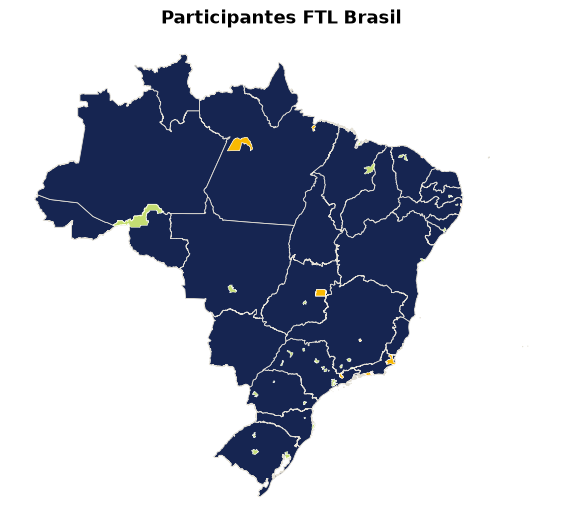

In [85]:
import matplotlib.pyplot as plt
import matplotlib as mpl

fig, ax = plt.subplots(figsize=(7, 8))

brasil_gdf.plot(
    ax=ax,
    color="#162551",
    edgecolor="#E6E2D7",
    linewidth=0.6
)

cmap = plt.cm.Wistia
norm = mpl.colors.Normalize(vmin=1, vmax=3)

new_gdf.plot(
    ax=ax,
    column='num_part',
    markersize=30,
    cmap=cmap,
    norm=norm,
    alpha=0.85,
    edgecolor='white',
    linewidth=0.4
)

# Legend/colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# cbar = fig.colorbar(sm, ax=ax, shrink=0.6, pad=0.02)
# cbar.set_ticks([1, 2, 3])
# cbar.set_label('Número de participantes')

ax.set_title('Participantes FTL Brasil', fontsize=13, fontweight='bold')
ax.set_axis_off()

plt.show()

 ##  É possível melhorar esse mapa? Certamente

 Mostra pra gente alguma ideia sua! 


Ainda não sabe o que é spatial query?

 - Nao mosca e corre lá para ver nossas aulas de introducao em python + GIS
 - link github: [github-ftl-brasil](https://github.com/ftl-brazil-2026/gis-python-basics)

# Mapa interativo

O mapa estático é ótimo pra imprimir ou botar num slide, mas pra explorar dado geoespacial no dia a dia a gente quase sempre quer algo clicável, dar zoom, ver o nome de cada cidade, etc.

Aqui usamos [Folium](https://python-visualization.github.io/folium/), que é basicamente Python conversando com [Leaflet.js](https://leafletjs.com/) por baixo dos panos, você monta o mapa em Python, e ele gera um HTML/JS autocontido que roda no navegador, sem precisar de servidor nenhum.

Caso voce nao esteja visualizando o mapa no seu terminal, é necessário dar um trust.
```
uv run jupyter trust fundamentals_gis_rs/week0/space_tech_ecossystem.ipynb
```

In [88]:
import folium
from folium.plugins import MarkerCluster

# o polígono do IBGE é bem detalhado (ótimo pra análise, pesado pra web) -- simplificamos
# só pra exibição, sem alterar brasil_gdf original
brasil_simple = brasil_gdf.to_crs(4326)
brasil_simple['geometry'] = brasil_simple.geometry.simplify(0.02, preserve_topology=True)

m = folium.Map(location=[-14.2, -51.9], zoom_start=4, tiles='cartodbpositron')

folium.GeoJson(
    brasil_simple,
    name='Estados',
    style_function=lambda feature: {
        'fillColor': '#f0f0f0',
        'color': '#898781',
        'weight': 0.8,
        'fillOpacity': 0.3,
    },
).add_to(m) #adiciona ao mapa 

#cluster = MarkerCluster(name='Participantes').add_to(m)
for _, row in gdf.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=6,
        color='#e63946',
        fill=True,
        fill_color='#e63946',
        fill_opacity=0.85,
        popup=folium.Popup(f"<b>{row['lugar_clean']}</b><br>{row['matched_address']}", max_width=250),
    ).add_to(m)

folium.LayerControl().add_to(m)
m

# Testando algumas APIs